## 1. Veri Yükleme ve Hazırlık

Teslim edilmiş siparişler üzerinde zaman serisi analizi gerçekleştirmek için gerekli veri dönüşümleri yapılır.
Zaman bazlı gruplama için yıl, ay, hafta ve gün kolonları oluşturulur.

In [ ]:
# Gerekli kütüphanelerin import edilmesi
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

DATA_PROCESSED = "../data/processed"

# Sipariş verilerinin yüklenmesi
fact_orders = pd.read_parquet(os.path.join(DATA_PROCESSED, "fact_orders.parquet"))

# Tarih alanlarının datetime formatına çevrilmesi
fact_orders["order_purchase_timestamp"] = pd.to_datetime(fact_orders["order_purchase_timestamp"])
fact_orders["order_date"] = pd.to_datetime(fact_orders["order_date"])

# Sadece teslim edilmiş siparişlerin filtrelenmesi
fact_delivered = fact_orders[fact_orders["order_status"] == "delivered"].copy()

# Zaman serisi analizleri için tarih bazlı kolonların oluşturulması
fact_delivered["order_year"]        = fact_delivered["order_date"].dt.year
fact_delivered["order_month_num"]   = fact_delivered["order_date"].dt.month
fact_delivered["order_week"]        = fact_delivered["order_date"].dt.isocalendar().week
fact_delivered["order_day_of_week"] = fact_delivered["order_date"].dt.dayofweek
fact_delivered["order_day_name"]    = fact_delivered["order_date"].dt.day_name()
fact_delivered["order_quarter"]     = fact_delivered["order_date"].dt.quarter

# Veri seti özeti
print(f"Toplam sipariş item sayısı : {len(fact_delivered):,}")
print(f"Tarih aralığı              : {fact_delivered['order_date'].min()} → {fact_delivered['order_date'].max()}")
print(f"Analiz süresi              : {(fact_delivered['order_date'].max() - fact_delivered['order_date'].min()).days} gün")

fact_delivered.head()

Toplam sipariş item sayısı : 106,283
Tarih aralığı              : 2016-09-15 00:00:00 → 2018-08-29 00:00:00
Analiz süresi              : 713 gün


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,review_count,total_item_value,order_date,order_year,order_month,order_month_num,order_week,order_day_of_week,order_day_name,order_quarter
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,1.0,72.19,2017-09-13,2017,2017-09,9,37,2,Wednesday,3
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,1.0,259.83,2017-04-26,2017,2017-04,4,17,2,Wednesday,2
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,1.0,216.87,2018-01-14,2018,2018-01,1,2,6,Sunday,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,1.0,25.78,2018-08-08,2018,2018-08,8,32,2,Wednesday,3
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,1.0,218.04,2017-02-04,2017,2017-02,2,5,5,Saturday,1


## 2. Aylık Satış Trendi

Aylık sipariş hacmi ve gelir performansının zaman içindeki değişimi analiz edilir.
Ay-ay büyüme oranları ve ortalama sepet değeri trendleri görselleştirilir.

,orders,revenue,avg_order_value,orders_mom,revenue_mom
order_month,,,,,
2017-01,718,97121.59,135.266838,NaN,NaN
2017-02,1585,199596.91,125.928650,120.752089,105.512399
2017-03,2436,307343.46,126.167266,53.690852,53.982073
2017-04,2201,285680.15,129.795616,-9.646962,-7.048567
2017-05,3399,427353.49,125.729182,54.429805,49.591594
2017-06,3015,372180.50,123.442952,-11.297440,-12.910387
2017-07,3770,481077.93,127.606878,25.041459,29.259306
2017-08,4030,505022.07,125.315650,6.896552,4.977185
2017-09,3970,522633.92,131.645824,-1.488834,3.487343


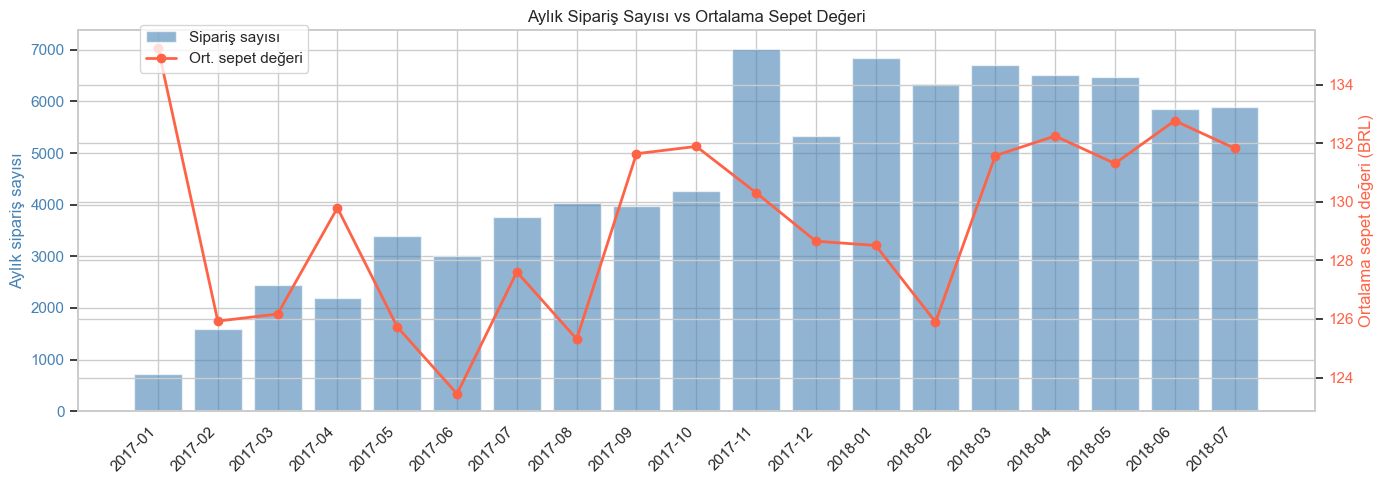

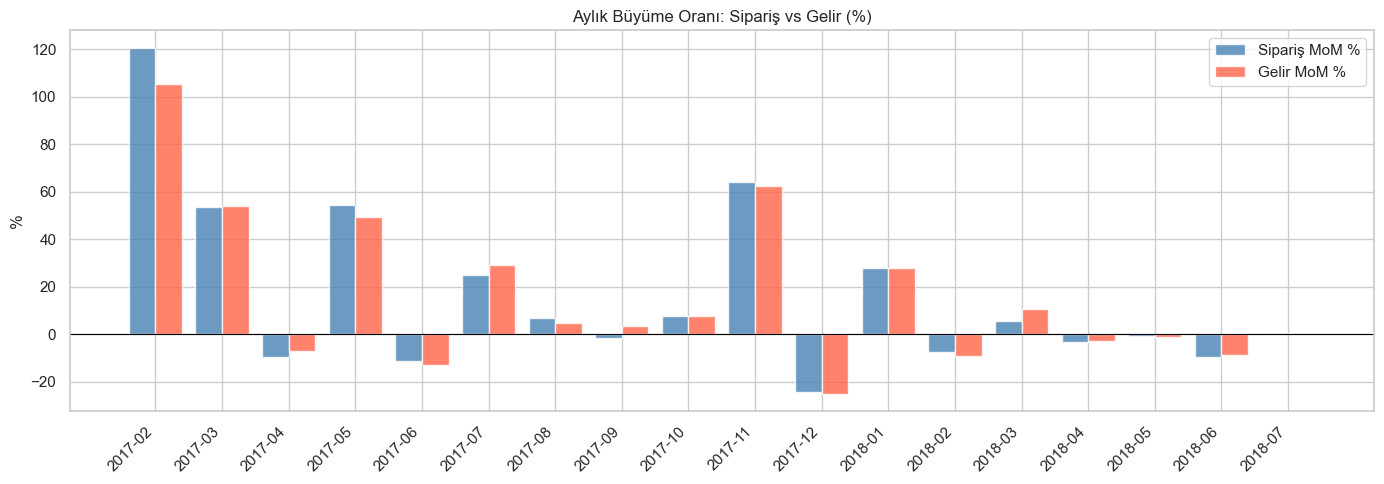

In [ ]:
# Aylık metrikler — ilk 3 ve son 1 ay kırpılıyor
monthly = (
    fact_delivered
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_item_value", "sum"),
    )
    .sort_index()
    .iloc[3:-1]  # İlk 3 ve son 1 ay hariç tutulur
)

# Aylık KPI'ların hesaplanması
monthly["avg_order_value"] = monthly["revenue"] / monthly["orders"]  # Ortalama sepet değeri
monthly["orders_mom"]      = monthly["orders"].pct_change() * 100   # Ay-ay % büyüme (sipariş)
monthly["revenue_mom"]     = monthly["revenue"].pct_change() * 100  # Ay-ay % büyüme (gelir)

display(monthly)

# Grafik 1: Sipariş hacmi (bar) + Ortalama sepet değeri (çizgi, sağ eksen)
fig, ax1 = plt.subplots(figsize=(14, 5))

# Sol eksen: Sipariş sayısı (bar grafik)
ax1.bar(range(len(monthly)), monthly["orders"], color="steelblue", alpha=0.6, label="Sipariş sayısı")
ax1.set_ylabel("Aylık sipariş sayısı", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly.index, rotation=45, ha="right")

# Sağ eksen: Ortalama sepet değeri (çizgi grafik)
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly["avg_order_value"], color="tomato", marker="o", linewidth=2, label="Ort. sepet değeri")
ax2.set_ylabel("Ortalama sepet değeri (BRL)", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

plt.title("Aylık Sipariş Sayısı vs Ortalama Sepet Değeri")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

# Grafik 2: MoM büyüme — sipariş ve gelir
mom = monthly[["orders_mom", "revenue_mom"]].dropna()
x = range(len(mom))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))

# Yan yana bar grafik ile MoM büyüme karşılaştırması
ax.bar([i - width/2 for i in x], mom["orders_mom"], width=width, label="Sipariş MoM %", color="steelblue", alpha=0.8)
ax.bar([i + width/2 for i in x], mom["revenue_mom"], width=width, label="Gelir MoM %", color="tomato", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)  # Sıfır çizgisi
ax.set_xticks(list(x))
ax.set_xticklabels(mom.index, rotation=45, ha="right")
ax.set_title("Aylık Büyüme Oranı: Sipariş vs Gelir (%)")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Sezonalite Analizi

Yıllık ve haftalık döngülerdeki satış desenlerinin incelenmesi yapılır.
Aylık bazda mevsimsel etkiler ve haftalık müşteri davranış kalıpları belirlenir.

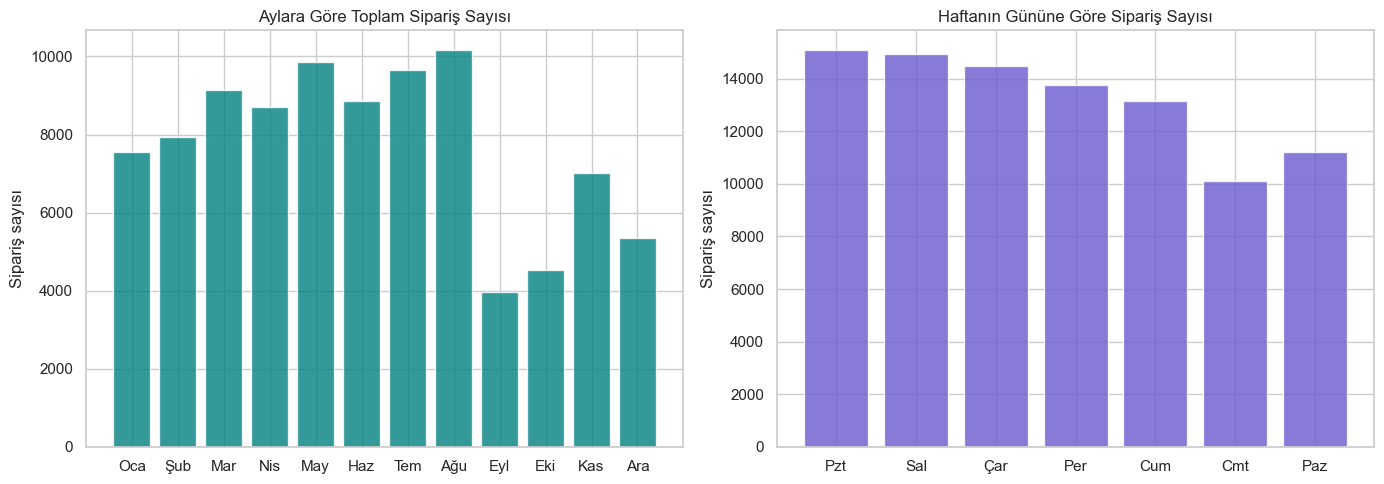

In [ ]:
# Aya göre ortalama sipariş sayısı (tüm yılları birleştirip aya göre grupla)
month_avg = (
    fact_delivered
    .groupby("order_month_num")["order_id"]
    .nunique()
)
month_names = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]

# Haftanın gününe göre sipariş dağılımı
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_names = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]

day_avg = (
    fact_delivered
    .drop_duplicates("order_id")  # Her sipariş bir kez sayılır
    .groupby("order_day_name")["order_id"]
    .count()
    .reindex(day_order)  # Haftanın günlerini sıralı tutar
)

# Grafik: Aylık ve haftalık sezonalite
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Aylara göre sezonalite
ax1.bar(range(1, 13), month_avg, color="teal", alpha=0.8)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_title("Aylara Göre Toplam Sipariş Sayısı")
ax1.set_ylabel("Sipariş sayısı")

# Sağ grafik: Haftanın günlerine göre dağılım
ax2.bar(range(7), day_avg, color="slateblue", alpha=0.8)
ax2.set_xticks(range(7))
ax2.set_xticklabels(day_names)
ax2.set_title("Haftanın Gününe Göre Sipariş Sayısı")
ax2.set_ylabel("Sipariş sayısı")

plt.tight_layout()
plt.show()

## 4. Kategori Bazında Trend Karşılaştırması

En yüksek gelirli 5 ürün kategorisinin zaman içindeki performans karşılaştırması yapılır.
Kategori bazında büyüme oranları ve trend yönleri belirlenir.

Top 5 kategori: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor']


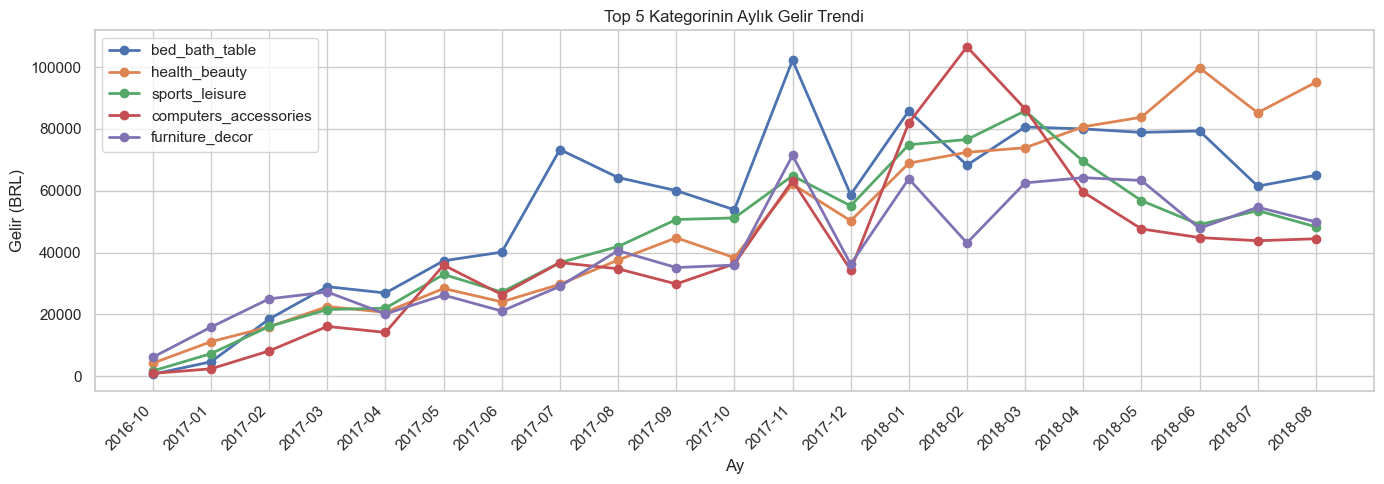


Kategori büyüme oranı (ilk ay → son ay):
  bed_bath_table: +10615.8%
  health_beauty: +2172.3%
  sports_leisure: +2789.3%
  computers_accessories: +5058.7%
  furniture_decor: +716.5%


In [ ]:
# En çok gelir getiren 5 kategori
top5_cats = (
    fact_delivered
    .groupby("product_category_name_english")["total_item_value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Top 5 kategori:", top5_cats)

# Bu kategorilerin aylık gelir trendi — 2016-09 hariç
cat_monthly = (
    fact_delivered[fact_delivered["product_category_name_english"].isin(top5_cats)]
    .groupby(["order_month", "product_category_name_english"])["total_item_value"]
    .sum()
    .reset_index()
)

# İlk ayın (2016-09) filtrelenmesi
cat_monthly = cat_monthly[cat_monthly["order_month"] >= "2016-10"]

# Ayların kronolojik sıralanması
sorted_months = sorted(cat_monthly["order_month"].unique())
cat_monthly["order_month"] = pd.Categorical(cat_monthly["order_month"], categories=sorted_months, ordered=True)
cat_monthly = cat_monthly.sort_values("order_month")

# Grafik: Her kategori için ayrı çizgi
plt.figure(figsize=(14, 5))
for cat in top5_cats:
    d = cat_monthly[cat_monthly["product_category_name_english"] == cat]
    plt.plot(d["order_month"].astype(str), d["total_item_value"], marker="o", linewidth=2, label=cat)

plt.xticks(rotation=45, ha="right")
plt.title("Top 5 Kategorinin Aylık Gelir Trendi")
plt.ylabel("Gelir (BRL)")
plt.xlabel("Ay")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# İlk vs son ay büyümesi
print("\nKategori büyüme oranı (ilk ay → son ay):")
for cat in top5_cats:
    d = cat_monthly[cat_monthly["product_category_name_english"] == cat].set_index("order_month")
    # İlk ve son ay arasındaki yüzdesel büyüme
    growth = (d["total_item_value"].iloc[-1] - d["total_item_value"].iloc[0]) / d["total_item_value"].iloc[0] * 100
    print(f"  {cat}: {growth:+.1f}%")


## 5. Bölgesel Trend Analizi

En yüksek sipariş hacmine sahip 3 eyaletin aylık performans karşılaştırması gerçekleştirilir.
Coğrafi bölgeler arası büyüme farklılıkları ve trend analizi yapılır.

Top 3 eyalet: ['SP', 'RJ', 'MG']


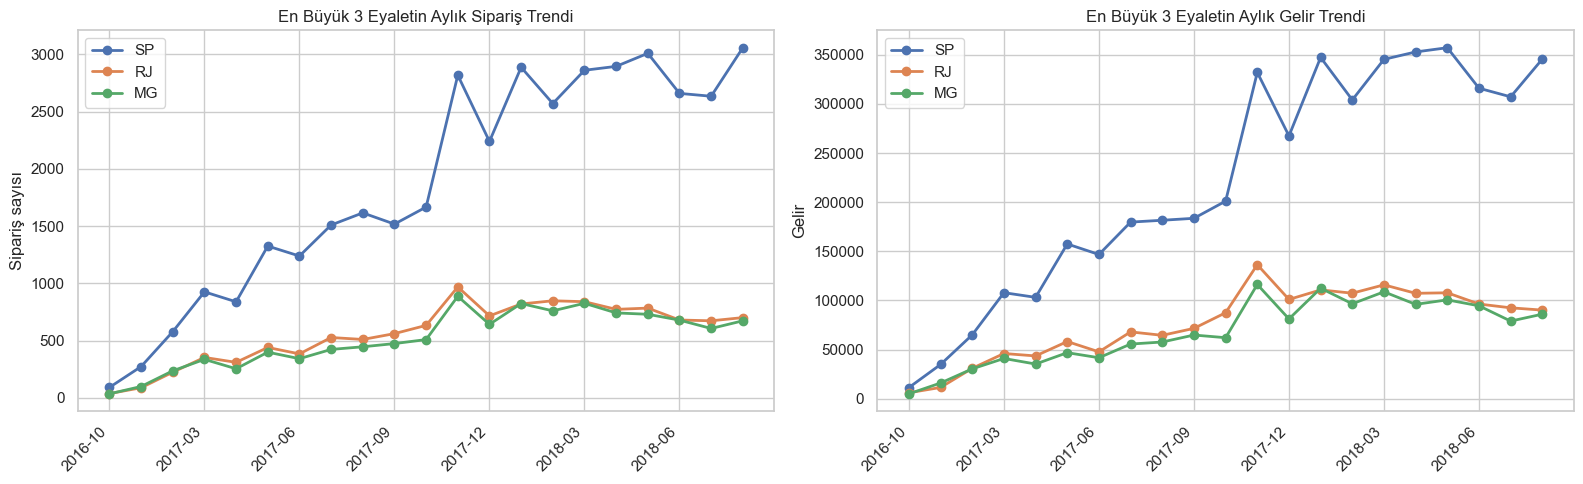

In [ ]:
# En çok sipariş alan 3 eyalet
top3_states = (
    fact_delivered
    .groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Top 3 eyalet:", top3_states)

# Bu eyaletlerin aylık trendleri
state_monthly = (
    fact_delivered[fact_delivered["customer_state"].isin(top3_states)]
    .groupby(["order_month", "customer_state"])
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_item_value", "sum"),
    )
    .reset_index()
)

# İlk ayın (2016-09) filtrelenmesi
state_monthly = state_monthly[state_monthly["order_month"] >= "2016-10"]

# Grafik: Sipariş ve gelir trendleri yan yana
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Sol grafik: Sipariş trendi
for state in top3_states:
    d = state_monthly[state_monthly["customer_state"] == state]
    ax1.plot(d["order_month"], d["orders"], marker="o", linewidth=2, label=state)

ax1.set_xticks(range(0, len(d["order_month"]), 3))  # Her 3 ayda bir etiket
ax1.set_xticklabels(d["order_month"].iloc[::3], rotation=45, ha="right")
ax1.set_title("En Büyük 3 Eyaletin Aylık Sipariş Trendi")
ax1.set_ylabel("Sipariş sayısı")
ax1.legend()

# Sağ grafik: Gelir trendi
for state in top3_states:
    d = state_monthly[state_monthly["customer_state"] == state]
    ax2.plot(d["order_month"], d["revenue"], marker="o", linewidth=2, label=state)

ax2.set_xticks(range(0, len(d["order_month"]), 3))
ax2.set_xticklabels(d["order_month"].iloc[::3], rotation=45, ha="right")
ax2.set_title("En Büyük 3 Eyaletin Aylık Gelir Trendi")
ax2.set_ylabel("Gelir")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Müşteri Davranış Trendi

Yeni müşteri kazanımı ve tekrar eden müşteri oranlarının zaman içindeki değişimi analiz edilir.
Müşteri sadakat seviyelerinin aylık gelişimi incelenir.

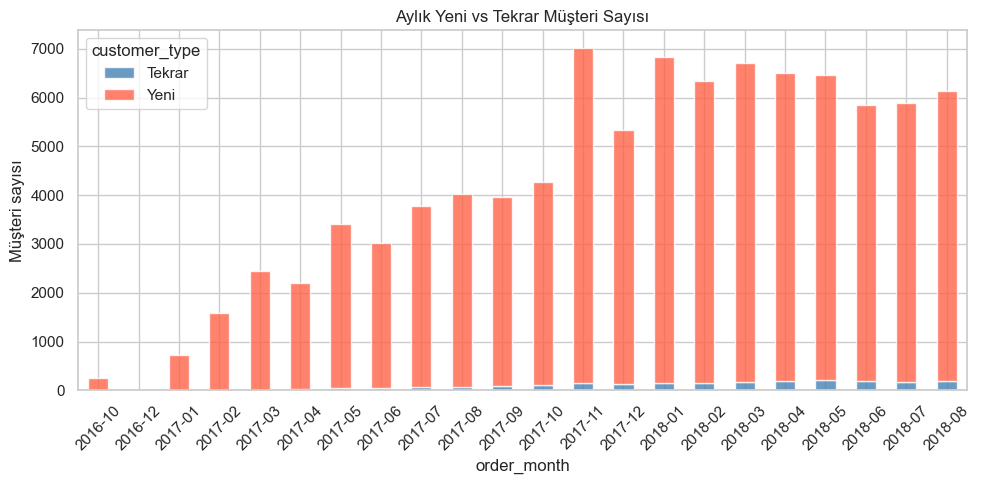

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Yığılmış bar grafik ile yeni vs tekrar müşteri karşılaştırması
customer_pivot.plot(kind="bar", stacked=True, ax=ax1, color=["steelblue", "tomato"], alpha=0.8)

ax1.tick_params(axis='x', rotation=45)
ax1.set_title("Aylık Yeni vs Tekrar Müşteri Sayısı")
ax1.set_ylabel("Müşteri sayısı")

plt.tight_layout()
plt.show()